Testing component parts of som-ffn_core

In [1]:
####  IMPORT FUNCTIONS
from selforganizingmap import SelfOrganizingMap
from feedforwardnetwork import FeedForwardNetwork


In [2]:
####  DEFINE CLASSES
som = SelfOrganizingMap()
ffn = FeedForwardNetwork()


In [3]:
####  STEP 1: Self-Organizing Map

##  Define input data for Self-Organising Map
som_input = {
    'mld': '../input-data/mld_clim_v2018.mat',
    'sss': '../input-data/sss_v2018.mat',
    'sst': '../input-data/sst_v2018.mat',
    # 'pressure': './input-data/pres_v2024.nc',
    # 'data_all': '../input-data/atm_co2_grid_v2024.nc',
    'data_all': '../input-data/atm_pco2_grid_v2018.mat'
    # 'chl': './input-data/chl_v2024.mat'
    # 'data_taka': './input-data/Taka_pCO2_eth_v2024.mat'
}

In [4]:
som_input

{'mld': '../input-data/mld_clim_v2018.mat',
 'sss': '../input-data/sss_v2018.mat',
 'sst': '../input-data/sst_v2018.mat',
 'data_all': '../input-data/atm_pco2_grid_v2018.mat'}

Self Organizing Map training ended after 0.3448679447174072 seconds


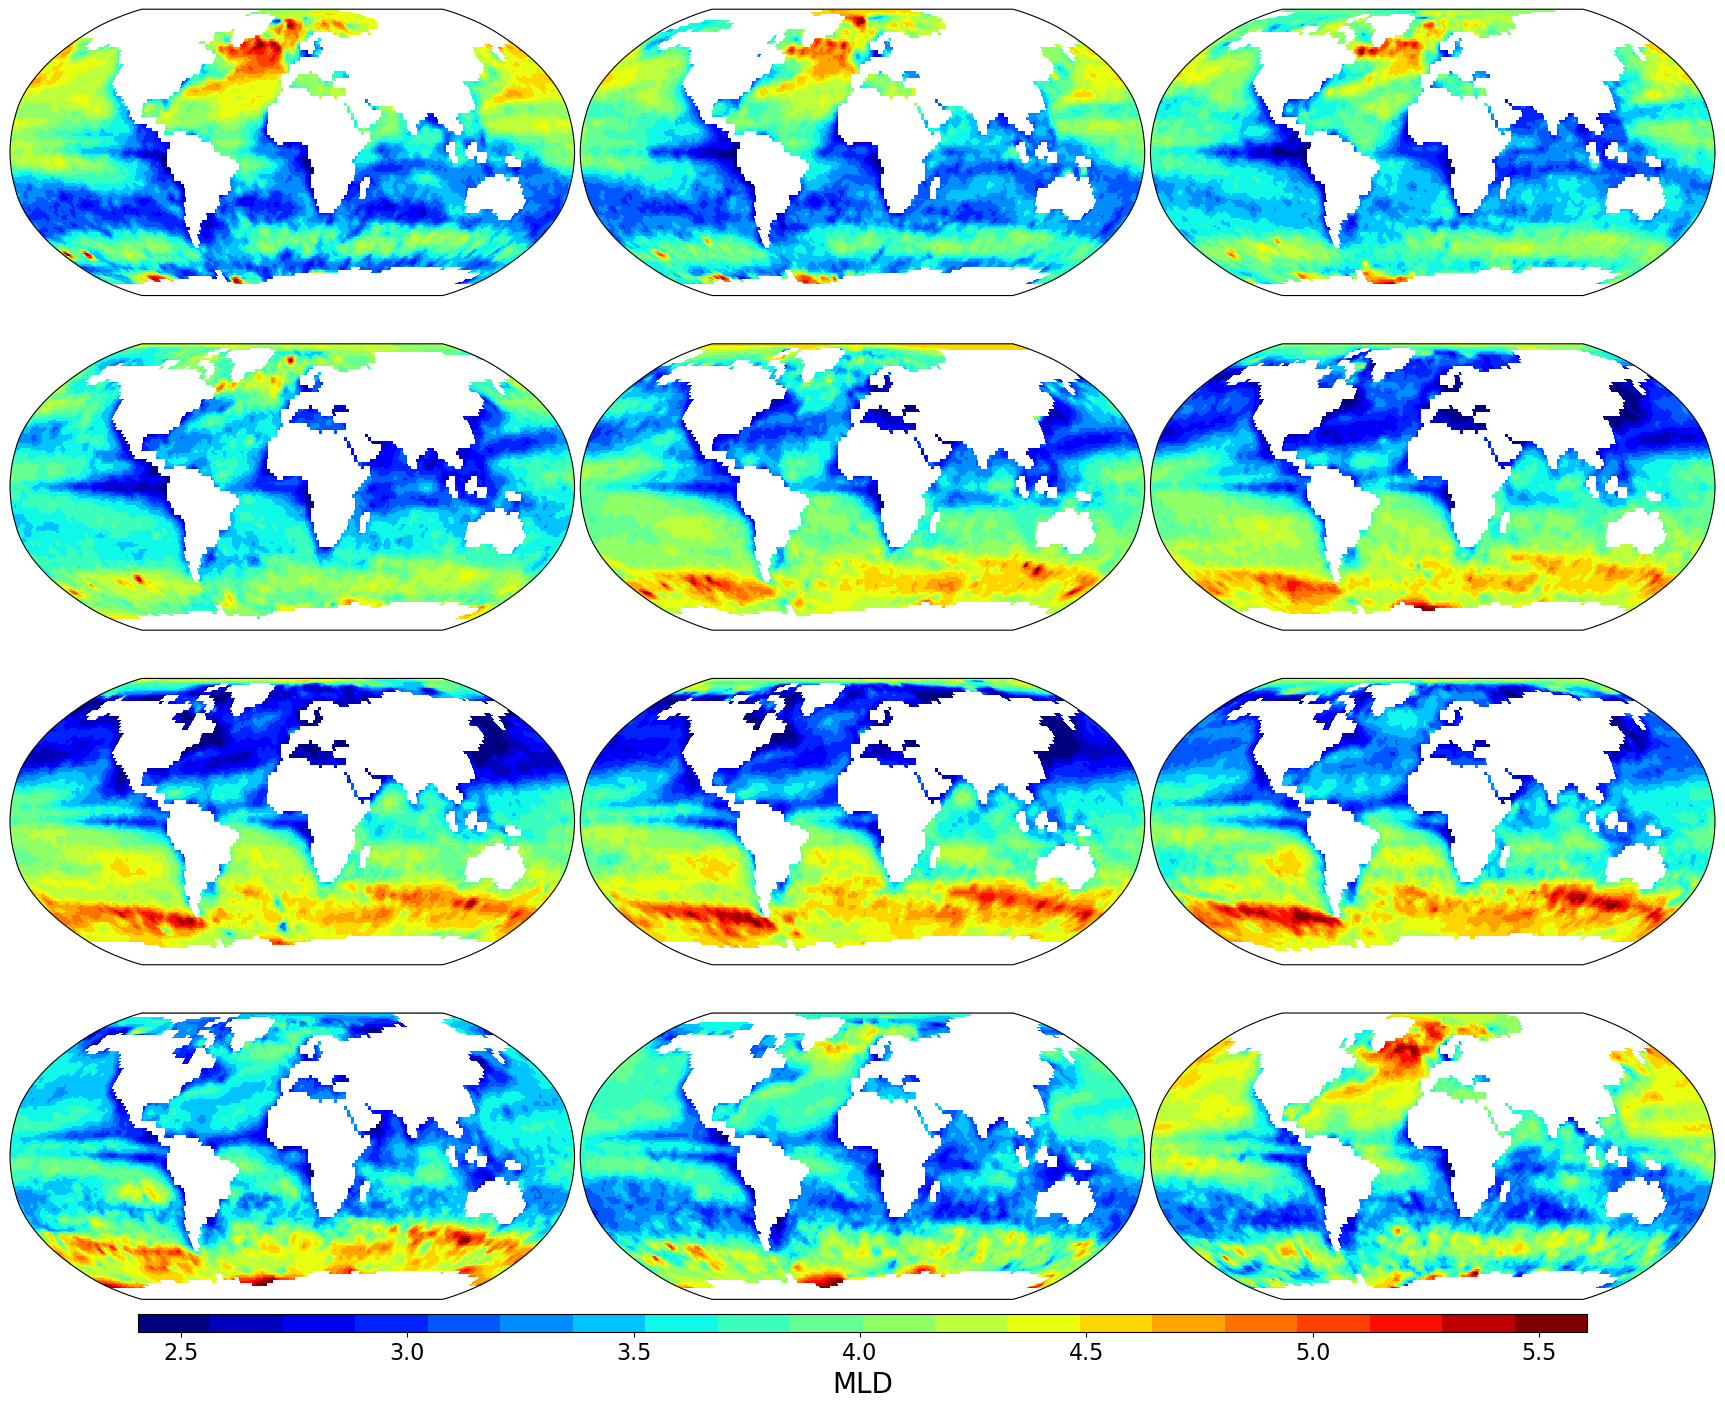

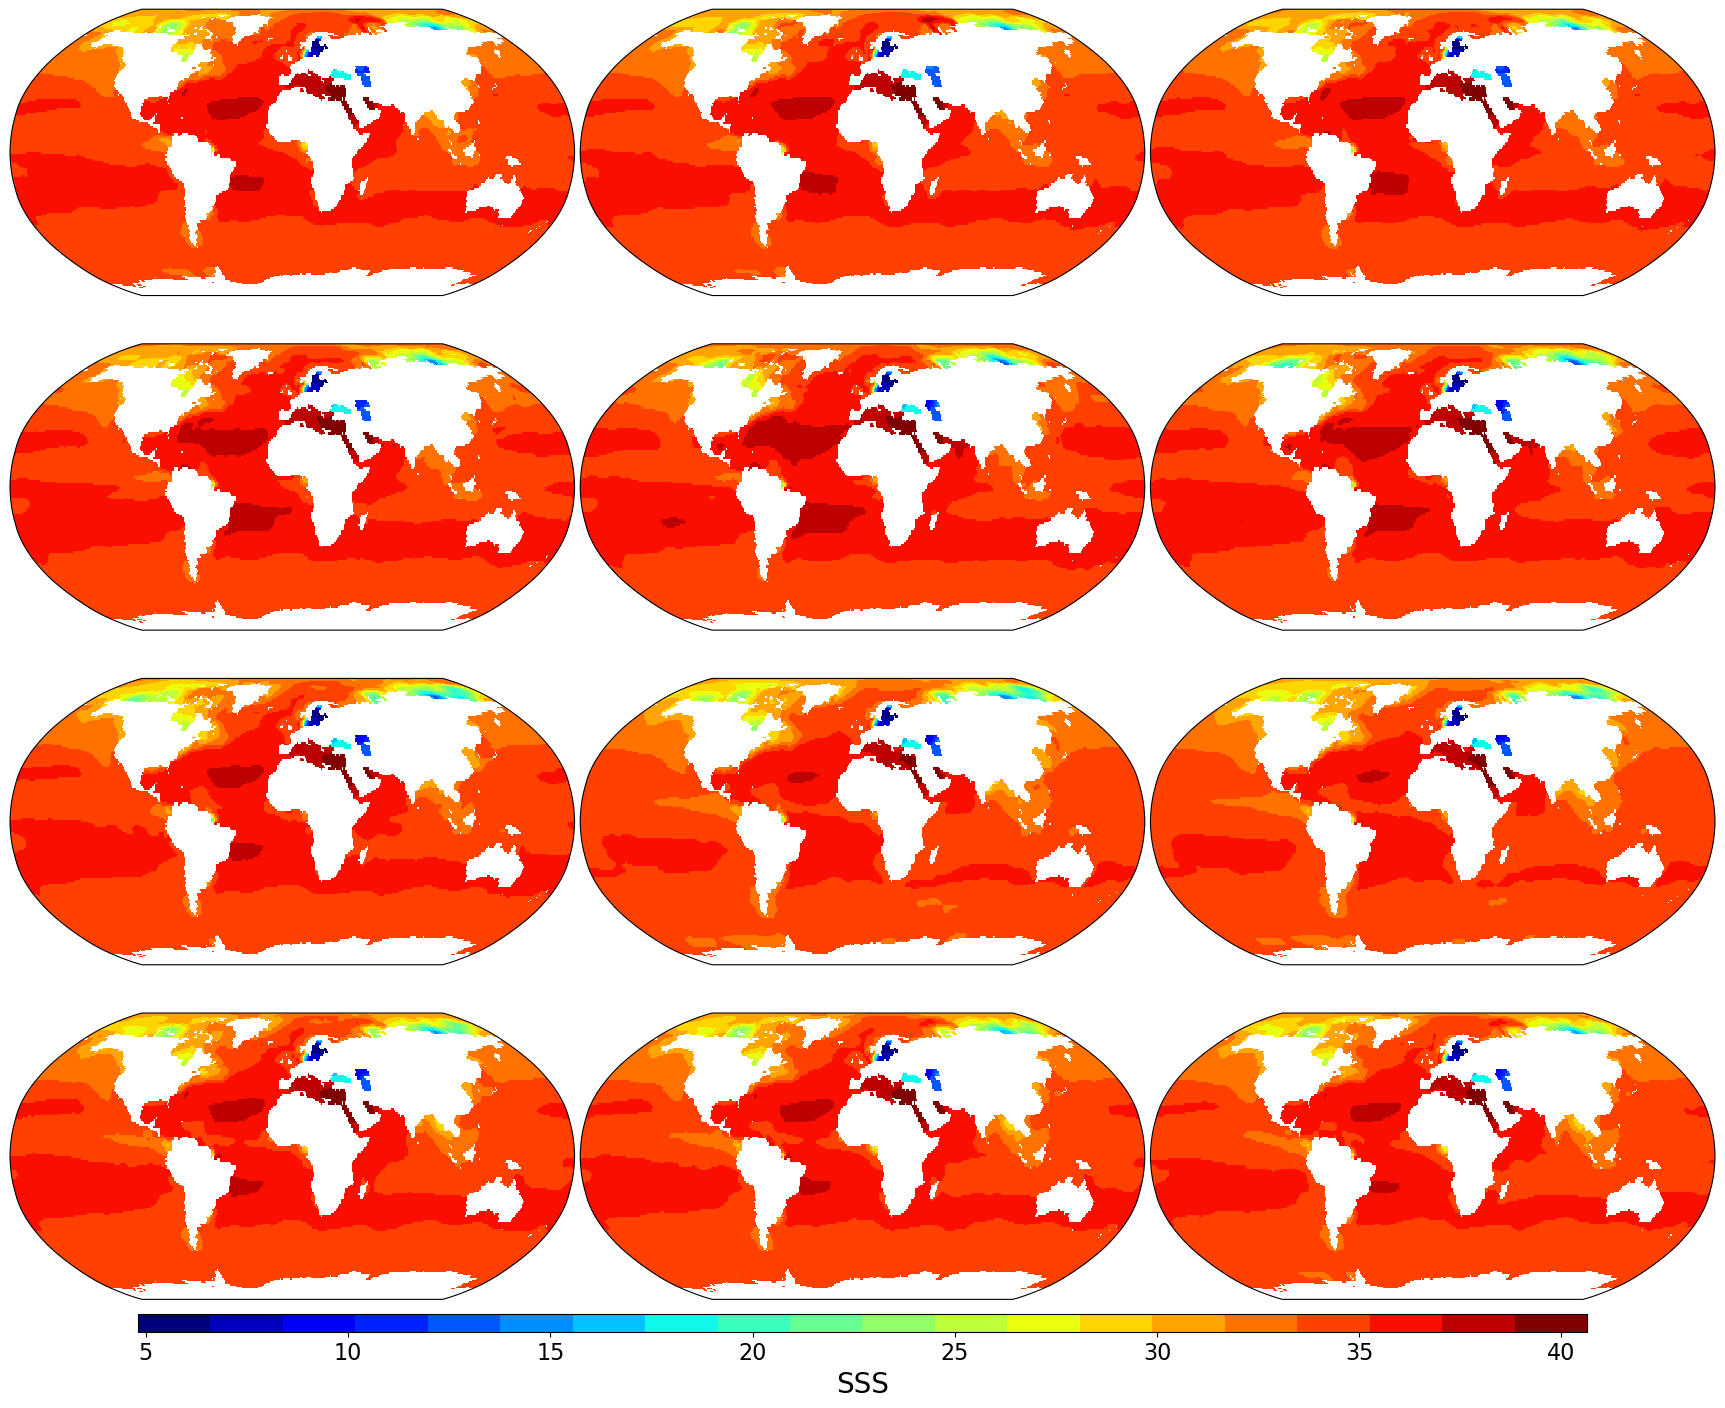

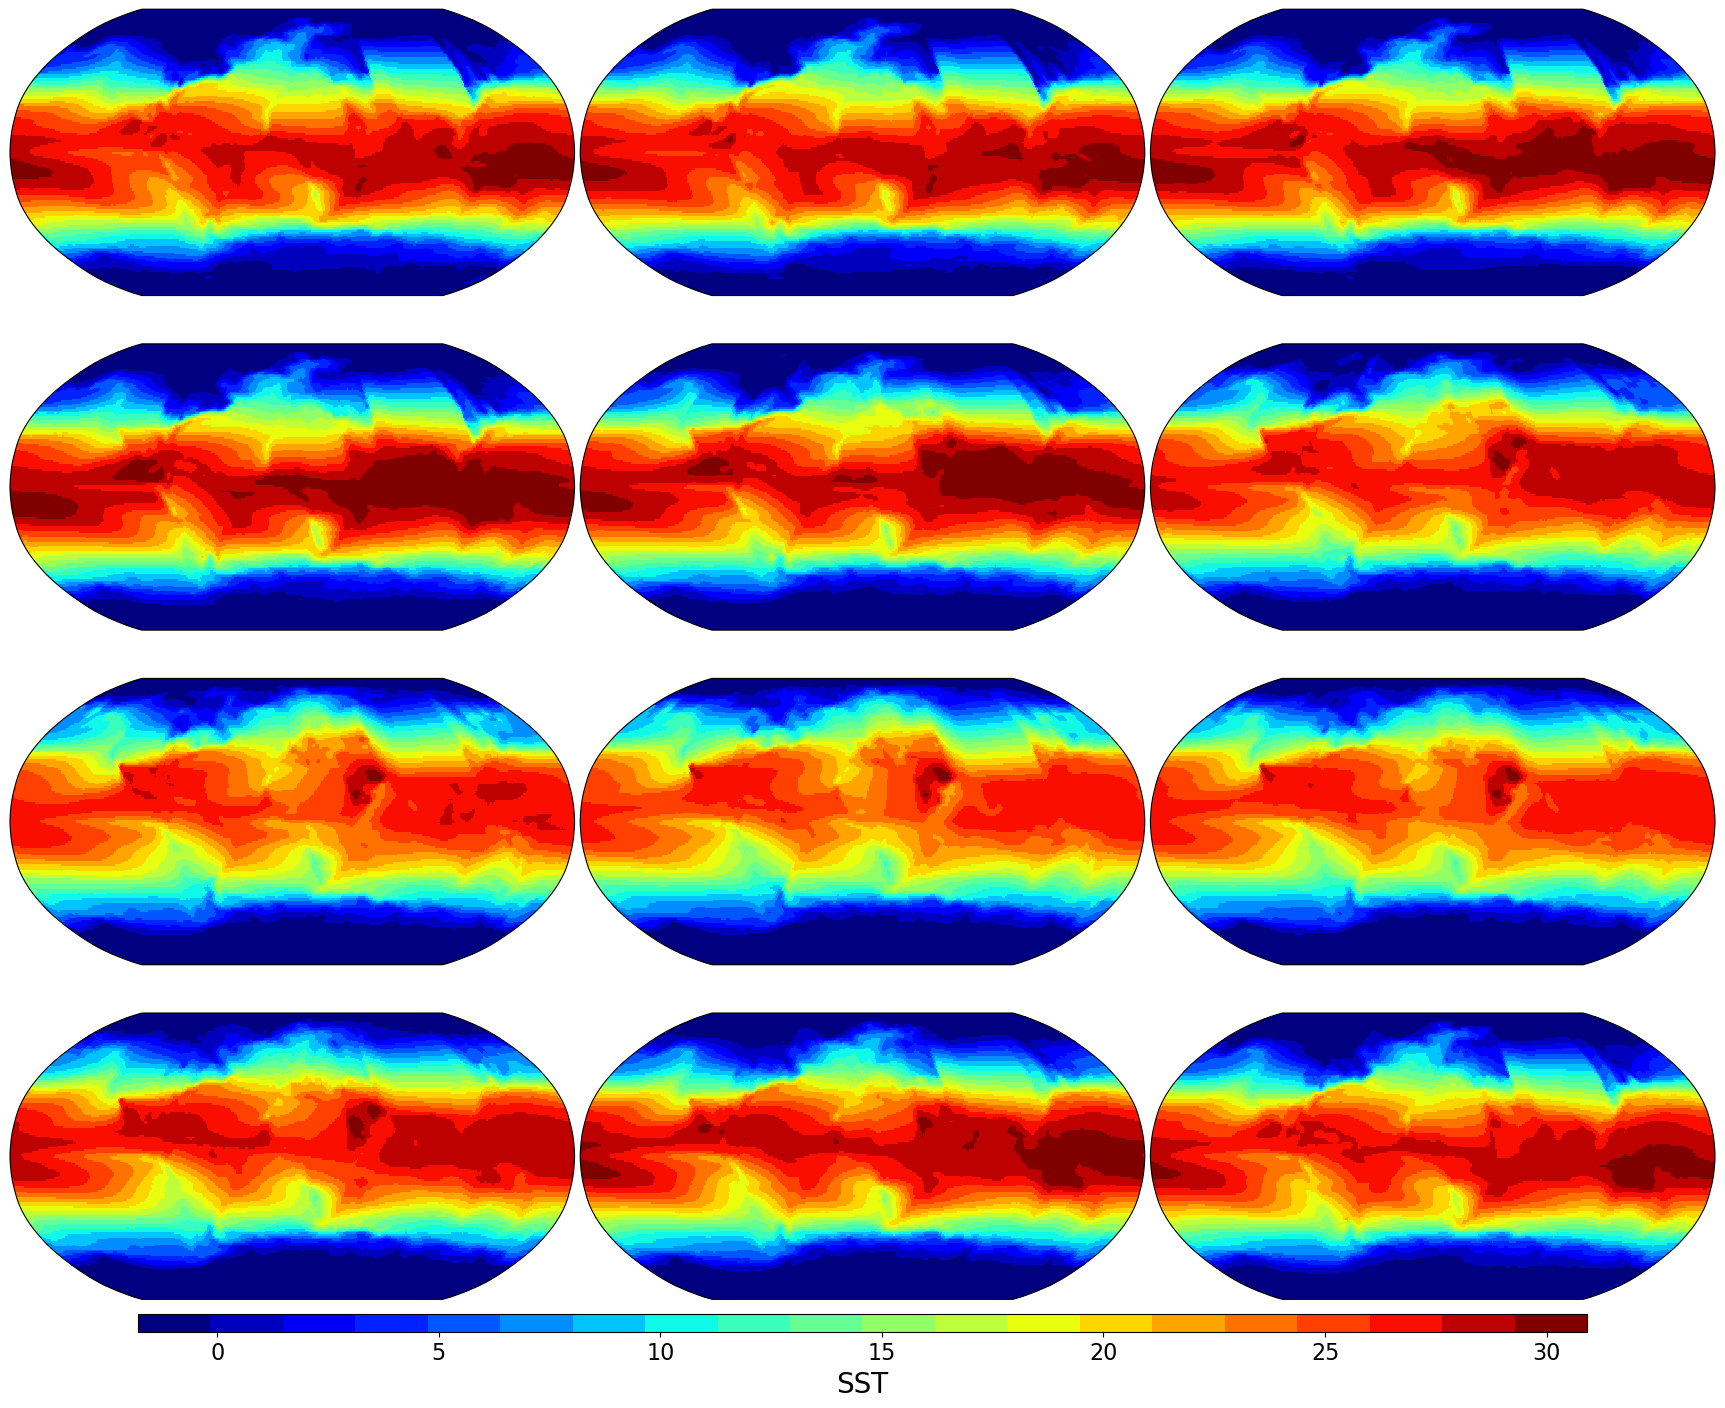

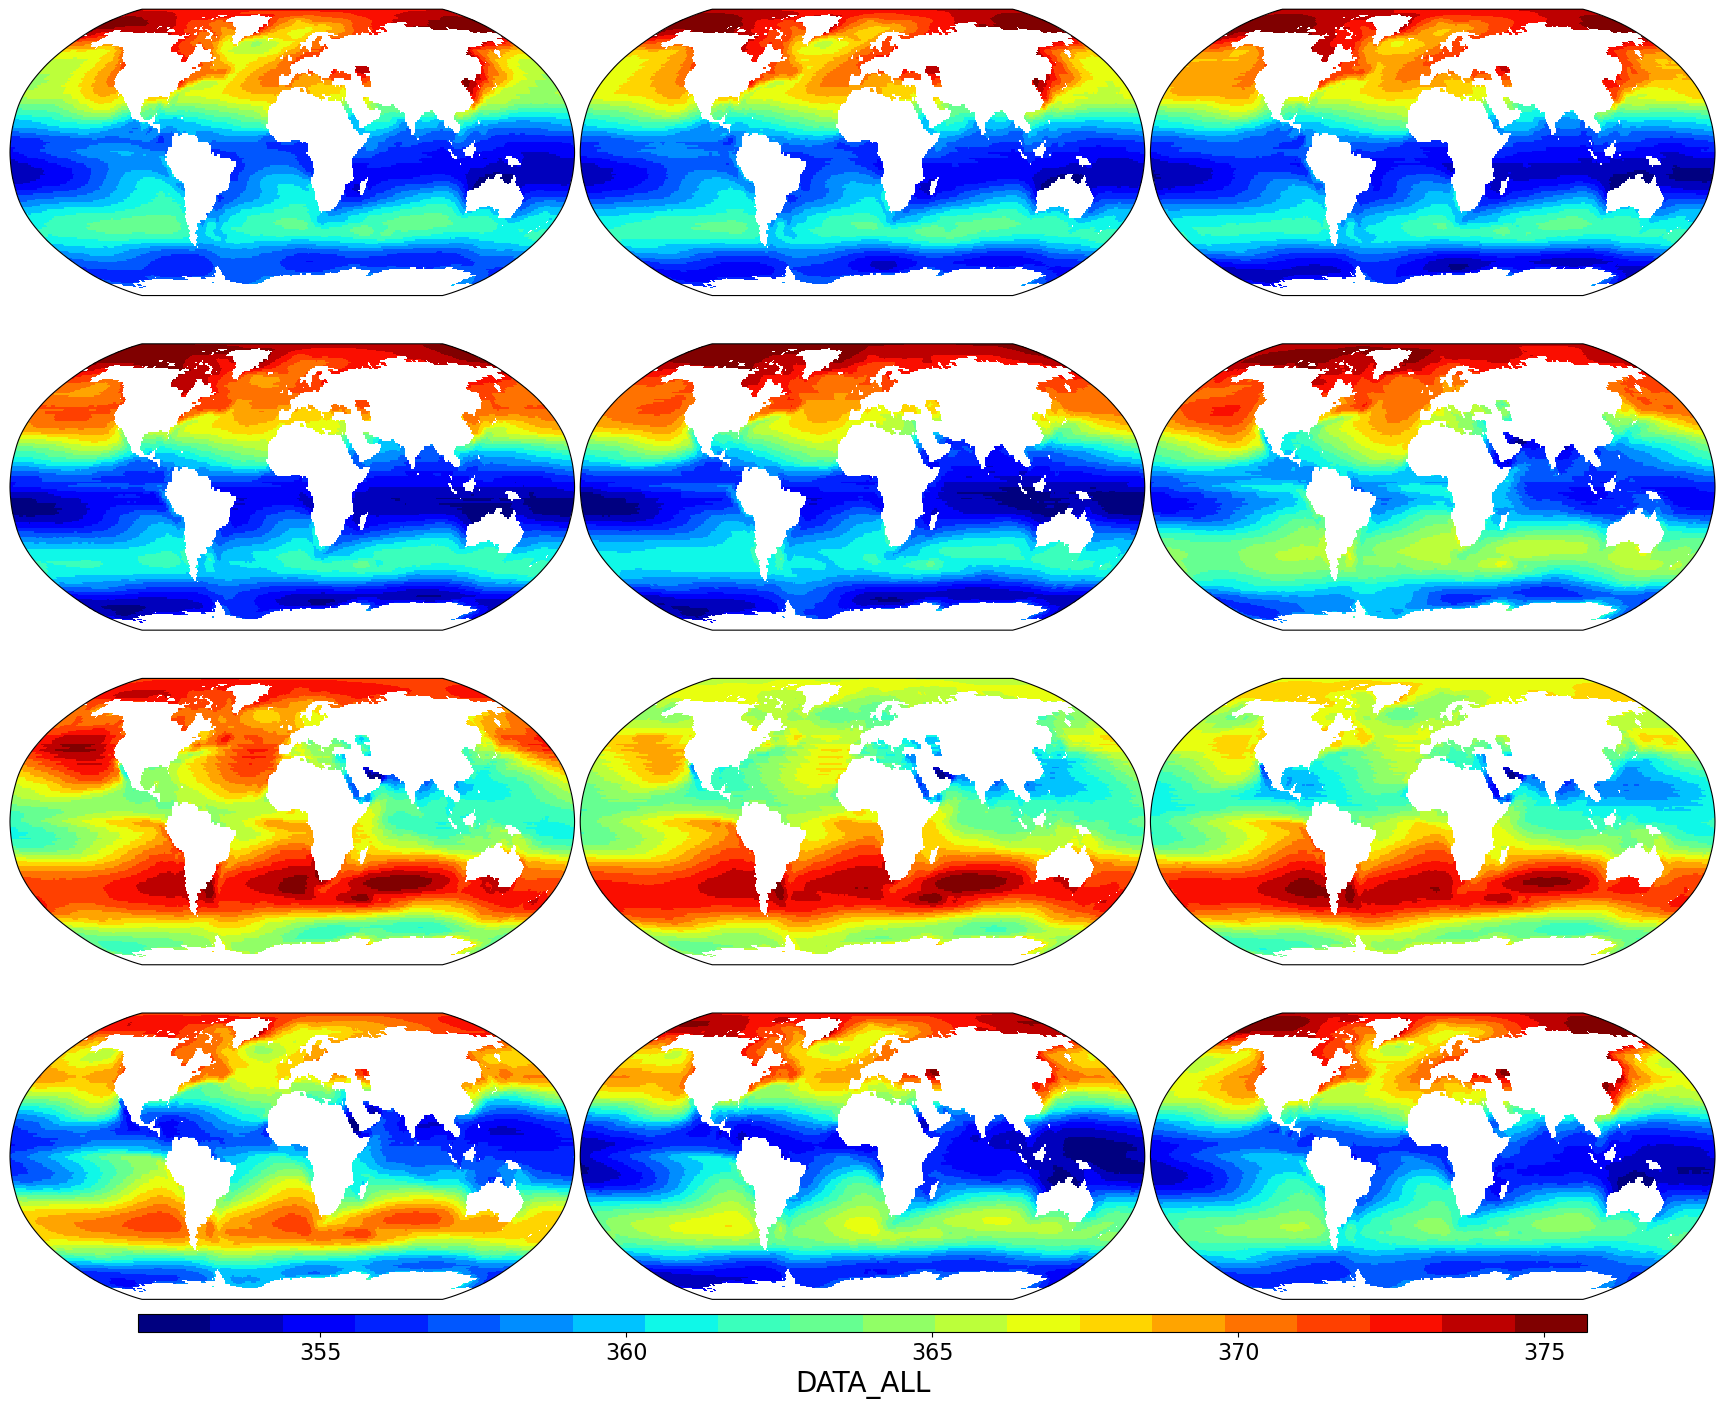

In [5]:
 ##  Call Functions for Feed Forward Network Operation
som.LoadInputData(som_input)
som.CalculateMeanMonths()
som.PlotInputsMonthly()  # optional
som.ReshapeRearrange()
som.IdentifyProvinces(som_sigma = 1.75, som_learning_rate = 1.0, number_of_epochs = 20000)  # values upwards of 200000 work best
# # som.LoadComparisonProvinces()  # optional TODO
# som.PlotProvinces(plot_type = 'mode-variability')  # optional TODO expand with additional visualisation options
som.WriteProvinces(fileext = 'nc')  # optional


In [ ]:
import scipy as sp

# test load
arr_obs = sp.io.loadmat('../input-data/pco2obsV2018.mat')['co2obs'].astype('float32')
arr_all = sp.io.loadmat('../input-data/pco2obsV2018.mat')



[]

In [12]:
arr_obs.shape

(456, 180, 360)

In [ ]:
# temporary - subset the current gridded float and socat dataset to try as an example 
import xarray as xr 
# socat_float_all = xr.open_dataset('../input-data/_socat_w_float.nc')['float_socat_mean'].values.astype('float32')
socat_float_all = xr.open_dataset('../input-data/_socat_w_float.nc')


In [ ]:
# save out datasets
socat_only = socat_float_all['fco2_ave_weighted'][120:-72]
socat_only.to_netcdf('../input-data/socat_only_1970_2017.nc')
float_socat_mean = socat_float_all['float_socat_mean'][120:-72]
float_socat_mean.to_netcdf('../input-data/float_socat_mean_1970_2017.nc')
float_adjusted_socat_mean = socat_float_all['float_adjusted_socat_mean'][120:-72]
float_adjusted_socat_mean.to_netcdf('../input-data/float_adjusted_socat_mean_1970_2017.nc')

In [34]:
##  Define input data for Feed Forward Network
ffn_input = {
    'mld': '../input-data/mld_clim_v2018.mat',
    'sss': '../input-data/sss_v2018.mat',
    'sst': '../input-data/sst_v2018.mat',
    'provinces': '../input-data/som-output_provinces.nc',
    # 'fco2_ave_weighted': '../input-data/socat_only_1970_2017.nc'
    # 'float_socat_mean': '../input-data/float_socat_mean_1970_2017.nc'
    'float_adjusted_socat_mean': '../input-data/float_adjusted_socat_mean_1970_2017.nc'
    # 'co2obs': '../input-data/pco2obsV2018.mat'
} 

In [35]:
##  Call Functions for Feed Forward Network Operation
ffn.LoadInputData(ffn_input)
ffn.CropInputData()
# ffn.PlotInputData()
ffn.PrepareInputs()
# ffn.MakeTrainModel(length_patience = 10)
ffn.MakeTrainModelLoop(length_patience = 10)
# ffn.PlotDiagnostic()  # FIXME not tested with "loop" approach
# ffn.PredictEstimate()
ffn.PredictEstimateLoop() 
# ffn.PlotPrediction(plot_type = 'mean-comparison')

mld               : 112.720 MB
sss               : 112.720 MB
sst               : 112.720 MB
provinces         : 2.966 MB
float_adjusted_socat_mean: 112.720 MB
lat               : 0.247 MB
lon               : 0.247 MB

Diagnostic : Shape of datasets
Dummy      : (29548800, 8) - 901.758 MB
Training   : (286094, 8) - 8.731 MB
Estimation : (17657100, 8) - 538.852 MB



Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_48                │ (25306, 8)             │            17 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (72.00 B)

 Trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_63                │ (15199, 8)             │            17 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_126 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (72.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 17 (72.00 B)

Epoch 1/500
475/475 - 3s - 5ms/step - R2Score: -3.5398e+01 - loss: 323.9879 - val_R2Score: -3.0711e+01 - val_loss: 299.3648
Epoch 2/500
475/475 - 1s - 2ms/step - R2Score: -2.0309e+01 - loss: 239.7341 - val_R2Score: -1.0803e+01 - val_loss: 169.6337
Epoch 3/500
475/475 - 1s - 2ms/step - R2Score: -4.9578e+00 - loss: 112.7285 - val_R2Score: -1.5337e+00 - val_loss: 72.4245
Epoch 4/500
475/475 - 1s - 2ms/step - R2Score: -7.3031e-01 - loss: 57.2484 - val_R2Score: -3.0416e-01 - val_loss: 47.6092
Epoch 5/500
475/475 - 1s - 2ms/step - R2Score: -2.4639e-01 - loss: 45.5855 - val_R2Score: -8.9246e-02 - val_loss: 41.9333
Epoch 6/500
475/475 - 1s - 2ms/step - R2Score: -6.5195e-02 - loss: 40.8281 - val_R2Score: 0.0213 - val_loss: 38.5257
Epoch 7/500
475/475 - 2s - 3ms/step - R2Score: 0.0342 - loss: 37.9759 - val_R2Score: 0.0850 - val_loss: 36.6192
Epoch 8/500
475/475 - 1s - 2ms/step - R2Score: 0.0929 - loss: 36.3391 - val_R2Score: 0.1260 - val_loss: 35.5437
Epoch 9/500
475/475 - 1s - 2ms/step - R2Scor

In [13]:
os.path.isfile('../input-data/pco2obsV2018.mat')

NameError: name 'os' is not defined

In [5]:
# from importlib import reload
# reload(FeedForwardNetwork)

ffn.PlotPrediction(plot_type = 'mean-comparison')

AttributeError: 'FeedForwardNetwork' object has no attribute 'pco2_estimate'